In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import networkx as nx

# Display options
pd.set_option('display.max_columns', 100)

# Path to your uploaded dataset
DATA_PATH = "./spotify_tracks_dataset.csv"
assert os.path.exists(DATA_PATH), f"File not found at {DATA_PATH}"

**Load and Basic Overview**

In [27]:
df = pd.read_csv(DATA_PATH)

# File size on disk (MB)
file_size_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)

print("=== DATASET OVERVIEW ===")
print(f"File size: {file_size_mb:.2f} MB")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
print("\nColumn names:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isna().sum().sort_values(ascending=False))

print("\nSample rows:")
display(df.head(3))

=== DATASET OVERVIEW ===
File size: 19.19 MB
Shape: 114,000 rows x 21 columns

Column names:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Dtypes:
Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Missing values per 

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


**Cleaning**

In [28]:
# Keep only rows that have basic identifiers and genre
required_cols = ["track_id", "track_name", "artists", "track_genre"]
missing_req = [c for c in required_cols if c not in df.columns]
if missing_req:
    raise ValueError(f"Missing required columns: {missing_req}")

# Drop exact duplicates on (track_id, track_name)
before = len(df)
df = df.drop_duplicates(subset=["track_id", "track_name"])
print(f"Dropped {before - len(df)} duplicate rows.")

# Strip whitespace in key text fields
for c in ["track_id", "track_name", "artists", "album_name", "track_genre"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Define the audio feature columns we’ll use
feature_cols = [
    "danceability","energy","loudness","speechiness",
    "acousticness","instrumentalness","liveness",
    "valence","tempo"
]

missing_feats = [c for c in feature_cols if c not in df.columns]
if missing_feats:
    raise ValueError(f"Missing expected audio features: {missing_feats}")

# Drop rows missing any of the core features
before = len(df)
df = df.dropna(subset=feature_cols)
print(f"Dropped {before - len(df)} rows with missing core audio features.")

# (Optional) keep only reasonable tempos and loudness to remove outliers
df = df[(df["tempo"] > 0) & (df["tempo"] < 300)]
df = df[(df["loudness"] < 0) & (df["loudness"] > -60)]  # typical dB range from Spotify
print(f"After outlier trimming: {len(df)} rows remain.")

print("\nCleaned feature stats:")
display(df[feature_cols].describe().T)


Dropped 24259 duplicate rows.
Dropped 0 rows with missing core audio features.
After outlier trimming: 89516 rows remain.

Cleaned feature stats:


,count,mean,std,min,25%,50%,75%,max
danceability,89516.0,0.563160,0.175245,0.05130,0.45000,0.576000,0.6920,0.985
energy,89516.0,0.635122,0.255668,0.00002,0.45800,0.677000,0.8530,1.000
loudness,89516.0,-8.482180,5.174902,-46.59100,-10.31100,-7.180000,-5.1090,-0.001
speechiness,89516.0,0.087511,0.113247,0.02210,0.03600,0.049000,0.0859,0.965
acousticness,89516.0,0.328164,0.338159,0.00000,0.01710,0.188000,0.6250,0.996
instrumentalness,89516.0,0.172529,0.323096,0.00000,0.00000,0.000057,0.0937,1.000
liveness,89516.0,0.216478,0.194308,0.00925,0.09820,0.132000,0.2780,1.000
valence,89516.0,0.470353,0.262343,0.00000,0.25000,0.458000,0.6830,0.995
tempo,89516.0,122.257618,29.699983,30.20000,99.50025,122.020000,140.0820,243.372


**Genre distribution**

In [29]:
genre_counts = df["track_genre"].value_counts()
print("Unique genres:", df["track_genre"].nunique())
display(genre_counts.head(15))

# (Optional) Filter out extremely rare genres (e.g., < 10 tracks)
MIN_PER_GENRE = 10
before = len(df)
df = df[df["track_genre"].map(genre_counts) >= MIN_PER_GENRE]
print(f"Filtered rare genres (<{MIN_PER_GENRE} tracks): {before - len(df)} rows removed.")
print("Remaining rows:", len(df))
print("Remaining unique genres:", df["track_genre"].nunique())

Unique genres: 113


track_genre
acoustic         1000
alt-rock          999
tango             999
afrobeat          999
cantopop          999
disney            998
bluegrass         998
study             998
chicago-house     998
forro             998
heavy-metal       997
ambient           996
black-metal       996
j-idol            994
anime             993
Name: count, dtype: int64

Filtered rare genres (<10 tracks): 0 rows removed.
Remaining rows: 89516
Remaining unique genres: 113


In [30]:
# Step 4 — Scale features
scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols])

# Keep an aligned copy of IDs/names for later
meta = df[["track_id", "track_name", "artists", "track_genre"]].reset_index(drop=True)
print("Scaled feature matrix shape:", X.shape)

Scaled feature matrix shape: (89516, 9)


Explained variance (2D): 47.90%


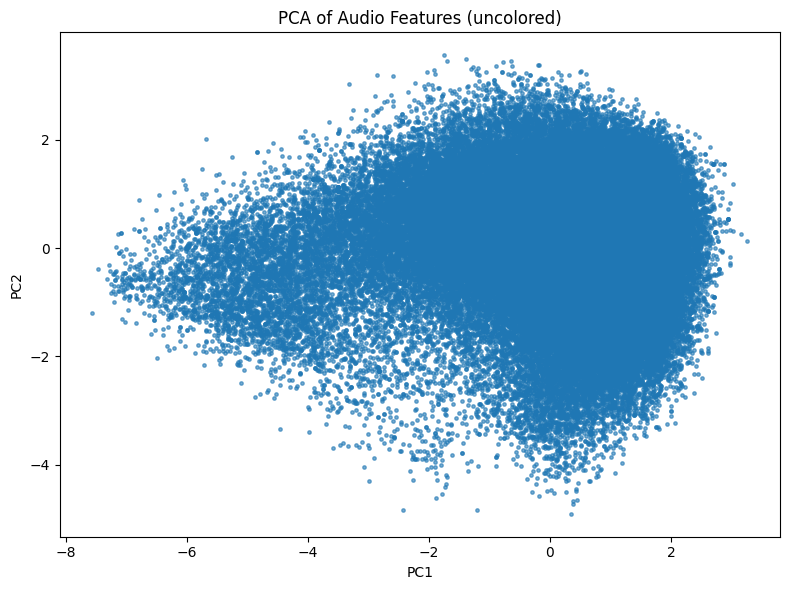

In [31]:
# Step 5 — PCA to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)
expl_var = pca.explained_variance_ratio_.sum()
print(f"Explained variance (2D): {expl_var:.2%}")

# Quick scatter (matplotlib only, no seaborn)
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=6, alpha=0.6)
plt.title("PCA of Audio Features (uncolored)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

# Save a PCA dataframe if useful
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "track_name": meta["track_name"],
    "artists": meta["artists"],
    "track_genre": meta["track_genre"]
})


In [32]:
# Step 6 — Memory-Safe kNN Similarity 
from sklearn.neighbors import NearestNeighbors
import numpy as np
import scipy.sparse as sp

print("Computing kNN similarity...")

# Use PCA for speed (optional but helps A LOT)
from sklearn.decomposition import PCA
pca_dim = 5
pca = PCA(n_components=pca_dim, random_state=42)
X_reduced = pca.fit_transform(X).astype(np.float32)

# Number of neighbors per song
k = 10   # You can increase later (10–20 works well)

nn = NearestNeighbors(
    n_neighbors=k+1,  
    metric="cosine",
    algorithm="auto",
    n_jobs=-1
)
nn.fit(X_reduced)

# distances[i] = distances from song i to its k neighbors
distances, indices = nn.kneighbors(X_reduced)

# Convert cosine distances → cosine similarity
similarities = 1 - distances

# Build sparse adjacency matrix
rows = np.repeat(np.arange(len(X_reduced)), k)
cols = indices[:, 1:].reshape(-1)      # remove self-neighbor
data = similarities[:, 1:].reshape(-1)

A = sp.csr_matrix((data, (rows, cols)), shape=(len(X_reduced), len(X_reduced)))

# Symmetrize (graph undirected)
A = A.maximum(A.T)

print("Sparse similarity graph created.")
print("Shape:", A.shape)
print("Non-zero edges:", A.nnz)
print("Density:", A.nnz / (A.shape[0] ** 2))


Computing kNN similarity...
Sparse similarity graph created.
Shape: (89516, 89516)
Non-zero edges: 1126862
Density: 0.00014062722232573144


In [33]:
# Step 7 — Build NetworkX Graph from Sparse kNN Matrix
import networkx as nx

# A is the adjacency matrix computed in Step 6
# (from the memory-safe kNN PCA method)

print("Building graph from sparse adjacency...")

G = nx.from_scipy_sparse_array(A, create_using=nx.Graph)

# Attach metadata (track names, artists, genres)
for i in range(len(meta)):
    G.nodes[i]["track_name"]  = meta.loc[i, "track_name"]
    G.nodes[i]["artists"]     = meta.loc[i, "artists"]
    G.nodes[i]["track_genre"] = meta.loc[i, "track_genre"]

print("Graph created successfully.")
print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())


Building graph from sparse adjacency...
Graph created successfully.
Nodes: 89516
Edges: 566338


=== NETWORK METRICS ===
Nodes: 89,516
Edges: 566,338
Density: 0.000141
Average Degree: 12.65
Min Degree: 10
Max Degree: 47
Average Clustering Coefficient: 0.3880


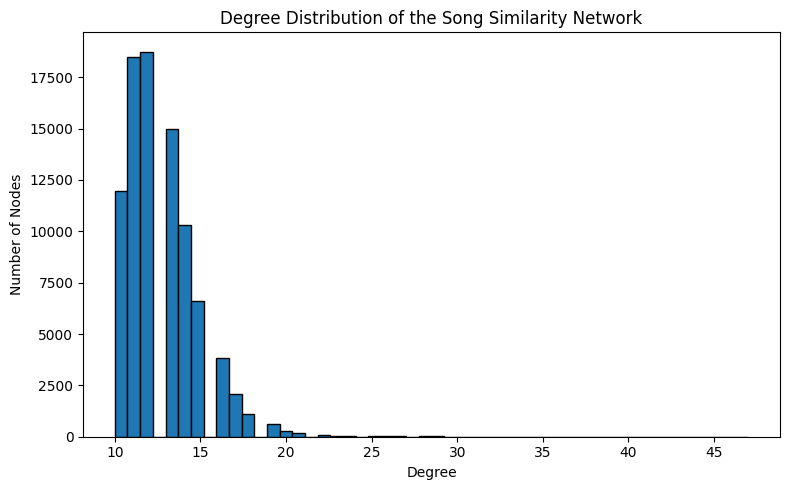

In [34]:
# Step 8 — Network Metrics
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

print("=== NETWORK METRICS ===")

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
density = nx.density(G)

# Degree values
degrees = np.array([d for _, d in G.degree()])

avg_degree = degrees.mean()
max_degree = degrees.max()
min_degree = degrees.min()

# Average clustering coefficient
avg_clust = nx.average_clustering(G, weight="weight")

# Print metrics
print(f"Nodes: {num_nodes:,}")
print(f"Edges: {num_edges:,}")
print(f"Density: {density:.6f}")
print(f"Average Degree: {avg_degree:.2f}")
print(f"Min Degree: {min_degree}")
print(f"Max Degree: {max_degree}")
print(f"Average Clustering Coefficient: {avg_clust:.4f}")

# Degree distribution plot
plt.figure(figsize=(8, 5))
plt.hist(degrees, bins=50, edgecolor='black')
plt.title("Degree Distribution of the Song Similarity Network")
plt.xlabel("Degree")
plt.ylabel("Number of Nodes")
plt.tight_layout()
plt.show()


In [35]:
# Step 9 — Community Detection (Louvain)
import community as community_louvain   # this is the python-louvain package

print("Running Louvain community detection...")

# Louvain works best when weights are included
partition = community_louvain.best_partition(G, weight="weight", resolution=1.0)

# Add community label to each node in the graph
nx.set_node_attributes(G, partition, "community")

# Convert partition dict → list aligned with nodes
communities = np.array([partition[n] for n in G.nodes()])

num_communities = len(set(communities))

print("=== COMMUNITY DETECTION ===")
print(f"Number of detected communities: {num_communities}")
print("Community sizes (top 10):")
(
    pd.Series(communities)
    .value_counts()
    .head(10)
    .rename("size")
    .to_frame()
)


Running Louvain community detection...
=== COMMUNITY DETECTION ===
Number of detected communities: 33
Community sizes (top 10):


,size
5,4492
1,4246
20,4162
0,4086
21,3756
22,3717
15,3652
27,3619
17,3399
26,3370


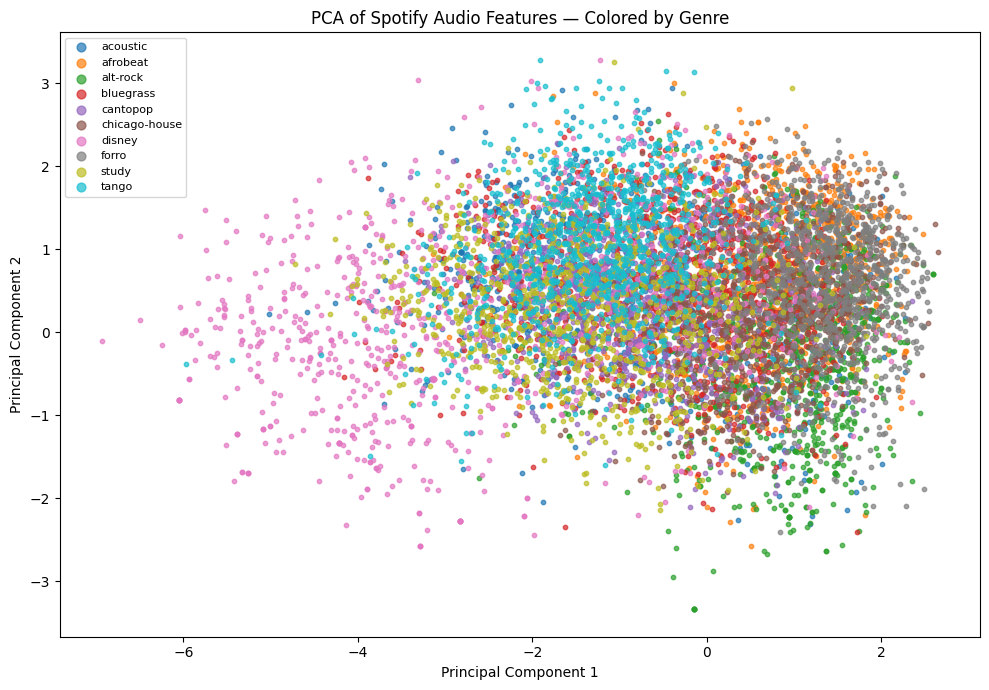

In [36]:
# Step 10 — PCA Scatter Colored by Genre

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# We assume you have:
# - X_pca  (shape: [n_songs, 2]) — from your PCA step
# - df     — your cleaned dataframe
# If not, recreate PCA quickly:

# If X_pca isn't defined (just in case):
# from sklearn.decomposition import PCA
# pca = PCA(n_components=2, random_state=42)
# X_pca = pca.fit_transform(X)

# Build PCA dataframe for plotting
pca_plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "genre": df["track_genre"].values
})

# Choose a subset of genres if many exist (optional but helpful)
top_genres = pca_plot_df["genre"].value_counts().head(10).index
mask = pca_plot_df["genre"].isin(top_genres)
pca_subset = pca_plot_df[mask]

plt.figure(figsize=(10, 7))

# Plot each genre separately so colors are distinct
genres = pca_subset["genre"].unique()
for g in genres:
    subset = pca_subset[pca_subset["genre"] == g]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=10,
        alpha=0.7,
        label=g
    )

plt.title("PCA of Spotify Audio Features — Colored by Genre")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()


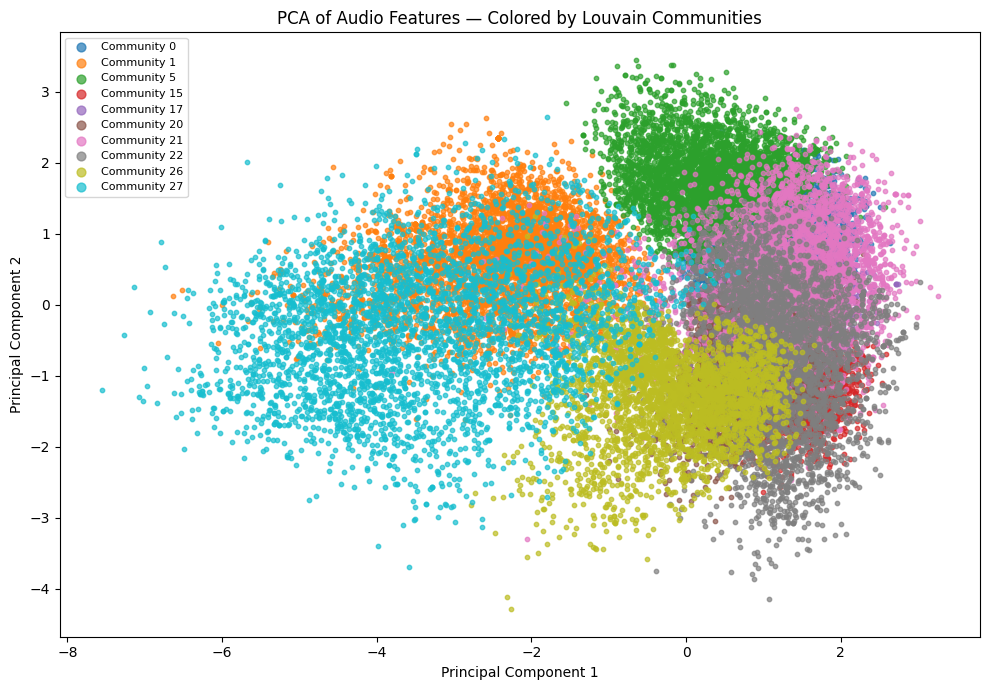

In [37]:
# Step 11 — PCA Scatter Colored by Community

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract communities from graph nodes
communities = np.array([G.nodes[i]["community"] for i in G.nodes()])

pca_comm_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "community": communities
})

# Get communities sorted by size (optional but nice)
comm_sizes = pca_comm_df["community"].value_counts().sort_values(ascending=False)
top_comms = comm_sizes.head(10).index  # only show largest 10 communities
mask = pca_comm_df["community"].isin(top_comms)
pca_subset = pca_comm_df[mask]

plt.figure(figsize=(10, 7))

unique_comms = sorted(pca_subset["community"].unique())

for c in unique_comms:
    subset = pca_subset[pca_subset["community"] == c]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=10,
        alpha=0.7,
        label=f"Community {c}"
    )

plt.title("PCA of Audio Features — Colored by Louvain Communities")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()


In [38]:
from pyvis.network import Network
import random

# Create a network visualizer
net = Network(
    height="700px",
    width="100%",
    notebook=True,
    bgcolor="#1E1E1E",
    font_color="white"
)

# Subsample nodes (for speed)
MAX_NODES = 3000
nodes = list(G.nodes())
if len(nodes) > MAX_NODES:
    nodes = random.sample(nodes, MAX_NODES)

# Add nodes with community-based color
for n in nodes:
    comm = G.nodes[n]['community']
    net.add_node(
        n,
        label=G.nodes[n]['track_name'],
        title=f"Genre: {G.nodes[n]['track_genre']}",
        group=comm
    )

# Add edges only connecting sampled nodes
for u, v, data in G.edges(data=True):
    if u in nodes and v in nodes:
        net.add_edge(u, v, value=data['weight'])

net.show("spotify_network.html")
print("Interactive visualization saved as spotify_network.html")


spotify_network.html
Interactive visualization saved as spotify_network.html


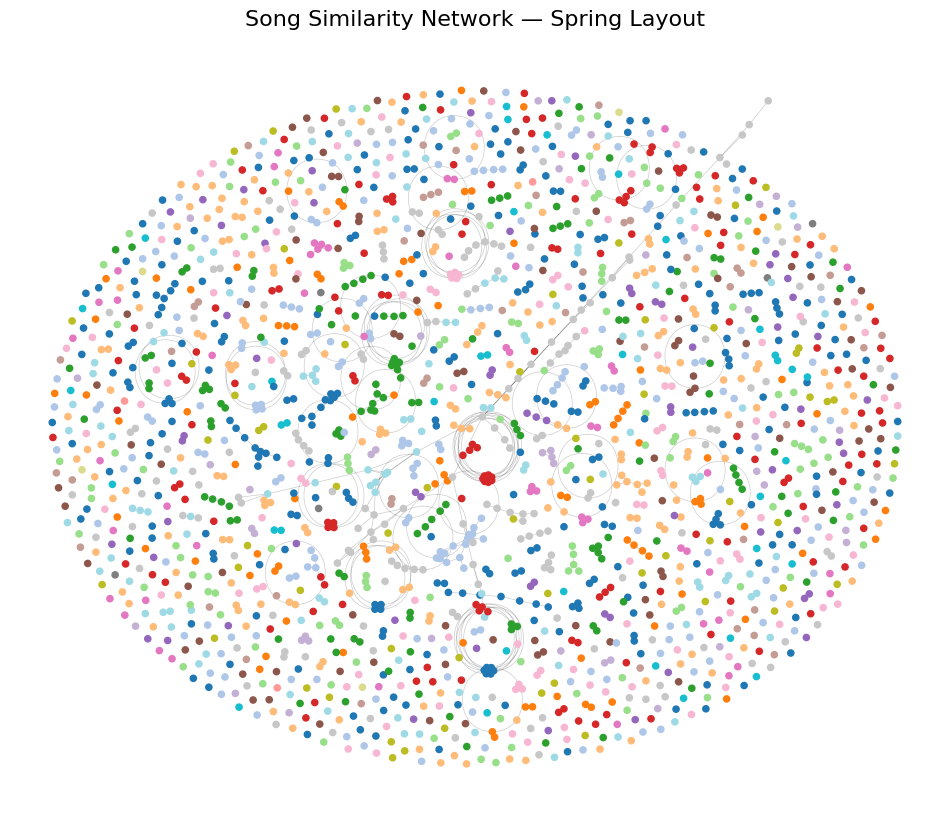

In [ ]:
# Spring layout on largest connected component

import networkx as nx
import matplotlib.pyplot as plt

# Use the biggest connected component
largest_cc = max(nx.connected_components(G), key=len)
H = G.subgraph(largest_cc).copy()

# Subsample if too large
MAX_NODES = 2000
if H.number_of_nodes() > MAX_NODES:
    sample_nodes = list(H.nodes())[:MAX_NODES]
    H = H.subgraph(sample_nodes).copy()

# Compute layout
pos = nx.spring_layout(H, seed=42, k=0.15)

# Color by community
colors = [H.nodes[n]["community"] for n in H.nodes()]

plt.figure(figsize=(12, 10))
nx.draw_networkx_nodes(H, pos, node_size=20, node_color=colors, cmap="tab20")
nx.draw_networkx_edges(H, pos, alpha=0.2, width=0.5)
plt.title("Song Similarity Network — Spring Layout", fontsize=16)
plt.axis("off")
# plt.show()

In [40]:
# Community–Genre Alignment

import pandas as pd
import numpy as np

# Build dataframe from node attributes
df_comm = pd.DataFrame({
    "community": [G.nodes[i]["community"] for i in G.nodes()],
    "genre": [G.nodes[i]["track_genre"] for i in G.nodes()]
})

df_comm.head()

crosstab = pd.crosstab(df_comm["community"], df_comm["genre"])
crosstab.head(10)  # show first 10 communities

def purity_score(y_true, y_pred):
    """Compute purity score. Higher = better."""
    contingency = pd.crosstab(y_pred, y_true).values
    return np.sum(np.max(contingency, axis=1)) / np.sum(contingency)

purity = purity_score(df_comm["genre"], df_comm["community"])
print(f"Purity Score: {purity:.4f}")

from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

# Encode genre names as numbers
genre_codes = pd.factorize(df_comm["genre"])[0]
comm_codes = df_comm["community"].values

nmi = normalized_mutual_info_score(genre_codes, comm_codes)
ari = adjusted_rand_score(genre_codes, comm_codes)

print(f"NMI: {nmi:.4f}")
print(f"ARI: {ari:.4f}")

summary = pd.DataFrame({
    "Metric": ["Purity", "NMI", "ARI"],
    "Value": [purity, nmi, ari]
})

summary


Purity Score: 0.0966
NMI: 0.1958
ARI: 0.0386


,Metric,Value
0,Purity,0.096620
1,NMI,0.195799
2,ARI,0.038600


### Community sampling and lyric collection
Sample representative tracks per community and persist metadata/lyrics for downstream analysis.

In [44]:
from pathlib import Path
import pandas as pd

SAMPLES_PER_COMMUNITY = 25
RANDOM_SEED = 42
OUTPUT_BASE = Path("community_samples")
OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

node_records = []
for node_id, attrs in G.nodes(data=True):
    node_records.append(
        {
            "node_id": node_id,
            "community": attrs.get("community"),
            "track_name": attrs.get("track_name"),
            "artists": attrs.get("artists"),
            "track_genre": attrs.get("track_genre"),
        }
    )

community_df = pd.DataFrame(node_records)
total_communities = community_df["community"].nunique()
if total_communities < 10:
    raise ValueError(f"Expected >=10 communities, found {total_communities}")

# Use the 10 largest communities by node count
community_order = community_df["community"].value_counts().head(10).index.tolist()

sampled_frames = []
for rank, community_id in enumerate(community_order, start=1):
    subset = community_df[community_df["community"] == community_id]
    if len(subset) < SAMPLES_PER_COMMUNITY:
        raise ValueError(
            f"Community {community_id} has only {len(subset)} songs (<{SAMPLES_PER_COMMUNITY})"
        )

    sampled = subset.sample(n=SAMPLES_PER_COMMUNITY, random_state=RANDOM_SEED)
    sampled = sampled.assign(community_rank=rank, community_id=community_id)
    sampled_frames.append(sampled)

    folder = OUTPUT_BASE / f"community {rank}"
    folder.mkdir(parents=True, exist_ok=True)

    lines = [f"{row['artists']} - {row['track_name']}" for _, row in sampled.iterrows()]
    (folder / "sampled_songs.txt").write_text("".join(lines), encoding="utf-8")

sampled_songs_df = pd.concat(sampled_frames, ignore_index=True)
sampled_songs_df.head()

,node_id,community,track_name,artists,track_genre,community_rank,community_id
0,2340,5,Amiga Mía,Los Prisioneros,alt-rock,1,5
1,55521,5,"Adada Mazhaida (From ""Paiya"")",Yuvan Shankar Raja;Rahul Nambiar;Saindhavi,k-pop,1,5
2,17046,5,Kev's Courtin' Song,Kevin Bloody Wilson,comedy,1,5
3,19114,5,Cozy Little Christmas,Katy Perry,dance,1,5
4,13464,5,Apples And Bananas (Phonics Song),CoComelon,children,1,5


In [57]:
from lyricsgenius import Genius
from pathlib import Path
from time import sleep

LYRICS_OUTPUT = Path("community_lyrics")
LYRICS_OUTPUT.mkdir(parents=True, exist_ok=True)


def load_env_file(path="../.env.local"):
    env_vars = {}
    env_path = Path(path)
    print(path)
    if not env_path.exists():
        raise FileNotFoundError(f"{path} not found; store your Genius API token there")
    with env_path.open() as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, value = line.split("=", 1)
            env_vars[key.strip()] = value.strip()
    return env_vars


GENIUS_API_KEY = load_env_file().get("GENIUS_ACCESS_TOKEN")
if not GENIUS_API_KEY:
    raise ValueError("GENIUS_ACCESS_TOKEN not found in .env.local")

genius = Genius(GENIUS_API_KEY, timeout=15, retries=3)


def fetch_song_lyrics(genius_client, track_name, artist_name):
    try:
        song = genius_client.search_song(track_name, artist_name)
    except Exception as exc:
        print(f"Failed to fetch {artist_name} - {track_name}: {exc}")
        return None
    if song is None:
        print(f"No lyrics returned for {artist_name} - {track_name}")
        return None
    return song.lyrics


community_corpora = {}
for community_rank, group in sampled_songs_df.groupby("community_rank"):
    lyrics_blobs = []
    print(f"Collecting lyrics for community {community_rank} ({len(group)} songs)...")
    for _, row in group.iterrows():
        lyrics = fetch_song_lyrics(genius, row["track_name"], row["artists"])
        if lyrics:
            lyrics_blobs.append(lyrics)
            # sleep(1)  # be a good API citizen
    corpus_text = "".join(lyrics_blobs)
    (LYRICS_OUTPUT / f"community_{community_rank}_lyrics.txt").write_text(
        corpus_text, encoding="utf-8"
    )
    community_corpora[community_rank] = corpus_text

community_corpora.keys()

../.env.local
Searching for "Amiga Mía" by Los Prisioneros...
Done.
Searching for "Adada Mazhaida (From "Paiya")" by Yuvan Shankar Raja;Rahul Nambiar;Saindhavi...
No results found for: 'Adada Mazhaida (From "Paiya") Yuvan Shankar Raja;Rahul Nambiar;Saindhavi'
No lyrics returned for Yuvan Shankar Raja;Rahul Nambiar;Saindhavi - Adada Mazhaida (From "Paiya")
Searching for "Kev's Courtin' Song" by Kevin Bloody Wilson...
Done.
Searching for "Cozy Little Christmas" by Katy Perry...
Done.
Searching for "Apples And Bananas (Phonics Song)" by CoComelon...
Done.
Searching for "Low" by Larry Gaaga;Wizkid...
Done.
Searching for "Just A Heart" by James Hand...
Done.
Searching for "Der Frühwirth" by Andreas Gabalier...
Done.
Searching for "Cómo Quieres Que Te Quiera" by Rosario...
Done.
Searching for "Conozco a los dos" by Frankie y Los Matadores...
No results found for: 'Conozco a los dos Frankie y Los Matadores'
No lyrics returned for Frankie y Los Matadores - Conozco a los dos
Searching for "Rain

KeyboardInterrupt: 